# Baseline Model Development
This notebook develops a baseline model for predicting hourly bike rental demand using Linear Regression.

Four progressively richer baseline versions are evaluated:<br>
V0：Mean Demand Reference Baseline<br>
V1：Numeric Weather Baseline<br>
V2：Time + Numeric Weather Baseline<br>
V3：Time + Numeric Weather + Conditions<br>

## 1. Load and validate model-ready data

In [26]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score


model_data = pd.read_csv(
    "../data/processed/model_ready_hourly_rental_data.csv",
    parse_dates=["hour", "date"]
)

model_data = (
    model_data
    .sort_values("hour")
    .reset_index(drop=True)
)

model_data.head()

,hour,direct_count,registered_count,total_count,date,hour_of_day,day_of_week,month,is_weekend,conditions,temperature_c,perceived_temperature_c,humidity,windspeed_kmh,holiday,is_holiday,is_workday
0,2011-01-01 00:00:00,3,13,16,2011-01-01,0,5,1,1,clear,3.3,3.0,81.0,0.0,Not a holiday,0,0
1,2011-01-01 01:00:00,8,32,40,2011-01-01,1,5,1,1,clear,2.3,2.0,80.0,0.0,Not a holiday,0,0
2,2011-01-01 02:00:00,5,27,32,2011-01-01,2,5,1,1,clear,2.3,2.0,80.0,0.0,Not a holiday,0,0
3,2011-01-01 03:00:00,3,10,13,2011-01-01,3,5,1,1,clear,3.3,3.0,75.0,0.0,Not a holiday,0,0
4,2011-01-01 04:00:00,0,1,1,2011-01-01,4,5,1,1,clear,3.3,3.0,75.0,0.0,Not a holiday,0,0


## 2. Define target and progressive baseline features

In [27]:
TARGET = "total_count"
# TARGET_REGISTERED = "registered_count"
# TARGET_DIRECT = "direct_count"

# V1: numeric weather only
FEATURES_V1 = [
    "temperature_c",
    "humidity",
    "windspeed_kmh",
]

In [28]:
# V2: numeric weather + basic time information
NUMERIC_FEATURES_V2 = [
    "temperature_c",
    "humidity",
    "windspeed_kmh",
    "is_holiday",
]
CATEGORICAL_FEATURES_V2 = [
    "hour_of_day",
    "day_of_week",
    "month",
]
FEATURES_V2 = NUMERIC_FEATURES_V2 + CATEGORICAL_FEATURES_V2

In [29]:
# V3: numeric weather + basic time information + weather condition category
NUMERIC_FEATURES_V3 = NUMERIC_FEATURES_V2.copy()

CATEGORICAL_FEATURES_V3 = (
    CATEGORICAL_FEATURES_V2.copy()
    + ["conditions"]
)
FEATURES_V3 = NUMERIC_FEATURES_V3 + CATEGORICAL_FEATURES_V3

## 3. Time-based train/test split

In [30]:
split_index = int(len(model_data) * 0.8)

train_data = model_data.iloc[:split_index].copy()
test_data = model_data.iloc[split_index:].copy()

y_train = train_data[TARGET]
y_test = test_data[TARGET]

print("Training rows:", len(train_data))
print("Test rows:    ", len(test_data))

print("\nTraining period:")
print(train_data["hour"].min(), "to", train_data["hour"].max())

print("\nTest period:")
print(test_data["hour"].min(), "to", test_data["hour"].max())

assert train_data["hour"].max() < test_data["hour"].min(), (
    "The training and test periods are not chronologically separated."
)

Training rows: 13903
Test rows:     3476

Training period:
2011-01-01 00:00:00 to 2012-08-07 11:00:00

Test period:
2012-08-07 12:00:00 to 2012-12-31 23:00:00


In [31]:
# check unseen categories in train set
columns_to_check = [
    "hour_of_day",
    "day_of_week",
    "month",
    "conditions",
]

for column in columns_to_check:
    train_categories = set(train_data[column].unique())
    test_categories = set(test_data[column].unique())

    unseen_categories = test_categories - train_categories

    print(f"{column}:")
    if unseen_categories:
        print("  Categories present in test but unseen in train:", unseen_categories)
    else:
        print("  No unseen categories in test set.")

hour_of_day:
  No unseen categories in test set.
day_of_week:
  No unseen categories in test set.
month:
  No unseen categories in test set.
conditions:
  No unseen categories in test set.


## 4. V0: Mean demand reference baseline

In [32]:
# metrics helper function
def regression_metrics(y_true, y_pred, model_name):
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    r2 = r2_score(y_true, y_pred)

    negative_predictions = int((y_pred < 0).sum())

    return pd.DataFrame(
        {
            "model": [model_name],
            "MAE": [mae],
            "RMSE": [rmse],
            "R2": [r2],
            "negative_predictions": [negative_predictions],
        }
    )

In [33]:
mean_prediction = y_train.mean()
y_pred_V0 = np.repeat(mean_prediction, len(y_test))

metrics_V0 = regression_metrics(
    y_test,
    y_pred_V0,
    "V0: Mean Reference"
)
display(metrics_V0.round(3))

,model,MAE,RMSE,R2,negative_predictions
0,V0: Mean Reference,174.985,232.608,-0.113,0


## 5. V1: Numeric weather baseline

In [34]:
X_train_V1 = train_data[FEATURES_V1]
X_test_V1 = test_data[FEATURES_V1]

display(X_train_V1.head())

model_V1 = LinearRegression()
model_V1.fit(X_train_V1, y_train)
y_pred_V1 = model_V1.predict(X_test_V1)

print("Number of predictions:", len(y_pred_V1))
print("First five predictions:", y_pred_V1[:5])

,temperature_c,humidity,windspeed_kmh
0,3.3,81.0,0.0
1,2.3,80.0,0.0
2,2.3,80.0,0.0
3,3.3,75.0,0.0
4,3.3,75.0,0.0


Number of predictions: 3476
First five predictions: [294.95496228 304.47551938 318.95433973 297.53530506 259.17846356]


In [35]:
# metrics： v0 vs. v1
metrics_V1 = regression_metrics(
    y_test,
    y_pred_V1,
    "V1: Numeric Weather"
)

results_V0_V1 = pd.concat(
    [
        metrics_V0,
        metrics_V1,
    ],
    ignore_index=True
)

display(results_V0_V1.round(3))

,model,MAE,RMSE,R2,negative_predictions
0,V0: Mean Reference,174.985,232.608,-0.113,0
1,V1: Numeric Weather,147.791,209.767,0.095,5


### Observation
MAE, RMSE of V1 are smaller than V0, which means numeric weather variables provide useful information for predicting hourly rental demand. 

However, the low R² shows that weather alone cannot explain most of the demand variation. Time-related patterns are expected in the next model version.

V1 also generates 5 negative predictions. Since rental demand cannot be negative in reality, this already reveals one limitation of using unrestricted Linear Regression for a non-negative count target.

## 6. V2: Time + numeric weather baseline

In [36]:
X_train_V2 = train_data[FEATURES_V2]
X_test_V2 = test_data[FEATURES_V2]

display(X_train_V2.head())

# apply one-hot encoding to hour_of_day, day_of_week and month
preprocessor_V2 = ColumnTransformer(
    transformers=[
        (
            "numeric",
            "passthrough",
            NUMERIC_FEATURES_V2,
        ),
        (
            "categorical",
            OneHotEncoder(
                drop="first",
                handle_unknown="ignore",
            ),
            CATEGORICAL_FEATURES_V2,
        ),
    ]
)

model_V2 = Pipeline(
    steps=[
        ("preprocessor", preprocessor_V2),
        ("regressor", LinearRegression()),
    ]
)

model_V2.fit(X_train_V2, y_train)
y_pred_V2 = model_V2.predict(X_test_V2)
print("Number of predictions:", len(y_pred_V2))
print("First five predictions:", y_pred_V2[:5])

,temperature_c,humidity,windspeed_kmh,is_holiday,hour_of_day,day_of_week,month
0,3.3,81.0,0.0,0,0,5,1
1,2.3,80.0,0.0,0,1,5,1
2,2.3,80.0,0.0,0,2,5,1
3,3.3,75.0,0.0,0,3,5,1
4,3.3,75.0,0.0,0,4,5,1


Number of predictions: 3476
First five predictions: [277.35789144 271.07847778 282.46152977 275.48394291 282.57978938]


In [37]:
# metrics comparasion
metrics_V2 = regression_metrics(
    y_test,
    y_pred_V2,
    "V2: Time + Numeric Weather"
)

results_V0_to_V2 = pd.concat(
    [
        metrics_V0,
        metrics_V1,
        metrics_V2,
    ],
    ignore_index=True
)

display(results_V0_to_V2.round(3))

,model,MAE,RMSE,R2,negative_predictions
0,V0: Mean Reference,174.985,232.608,-0.113,0
1,V1: Numeric Weather,147.791,209.767,0.095,5
2,V2: Time + Numeric Weather,112.023,160.593,0.469,345


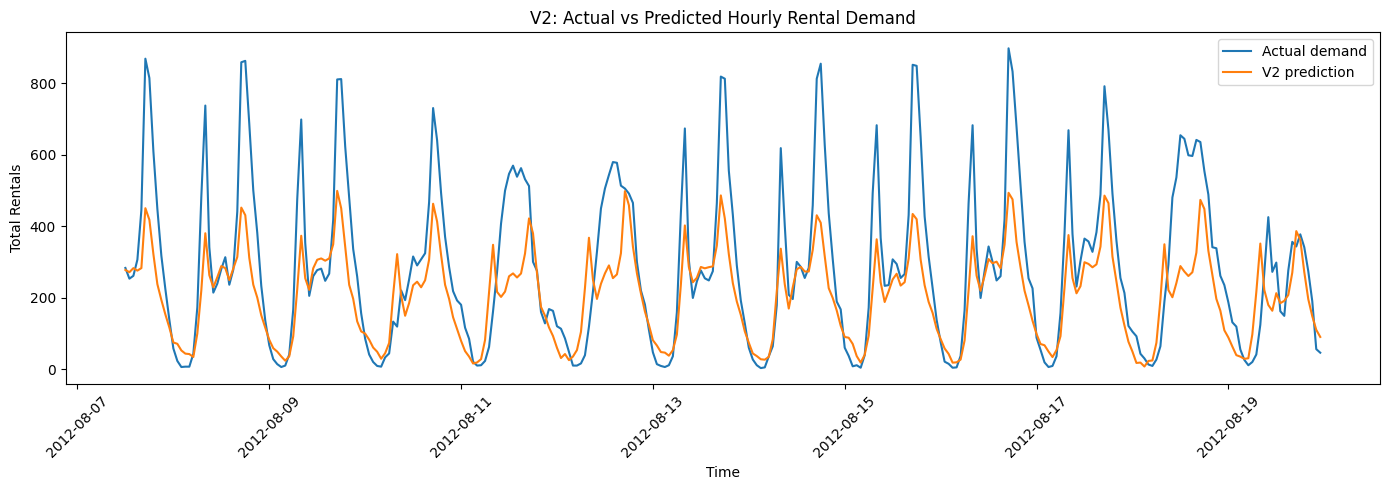

In [38]:
plot_size = min(300, len(test_data))

plt.figure(figsize=(14, 5))

plt.plot(
    test_data["hour"].iloc[:plot_size],
    y_test.iloc[:plot_size],
    label="Actual demand",
)

plt.plot(
    test_data["hour"].iloc[:plot_size],
    y_pred_V2[:plot_size],
    label="V2 prediction",
)

plt.title("V2: Actual vs Predicted Hourly Rental Demand")
plt.xlabel("Time")
plt.ylabel("Total Rentals")
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [39]:
# Coeffcient
feature_names_V2 = (
    model_V2
    .named_steps["preprocessor"]
    .get_feature_names_out()
)

coefficients_V2 = (
    model_V2
    .named_steps["regressor"]
    .coef_
)

coefficient_table_V2 = pd.DataFrame(
    {
        "feature": feature_names_V2,
        "coefficient": coefficients_V2,
    }
)

coefficient_table_V2["absolute_coefficient"] = (
    coefficient_table_V2["coefficient"].abs()
)

coefficient_table_V2 = (
    coefficient_table_V2
    .sort_values("absolute_coefficient", ascending=False)
    .reset_index(drop=True)
)

display(coefficient_table_V2.head(20))

,feature,coefficient,absolute_coefficient
0,categorical__hour_of_day_17,330.586843,330.586843
1,categorical__hour_of_day_18,306.675973,306.675973
2,categorical__hour_of_day_8,284.427537,284.427537
3,categorical__hour_of_day_19,211.983451,211.983451
4,categorical__hour_of_day_16,185.040863,185.040863
5,categorical__hour_of_day_7,157.404832,157.404832
6,categorical__hour_of_day_9,147.747516,147.747516
7,categorical__hour_of_day_12,143.370285,143.370285
8,categorical__hour_of_day_20,140.363882,140.363882
9,categorical__hour_of_day_13,137.516965,137.516965


In [40]:
month_coefficients_V2 = coefficient_table_V2[
    coefficient_table_V2["feature"].str.contains("month")
].sort_values("coefficient")

display(month_coefficients_V2)

,feature,coefficient,absolute_coefficient
22,categorical__month_8,-26.396426,26.396426
29,categorical__month_7,-15.302041,15.302041
34,categorical__month_9,-5.089141,5.089141
39,categorical__month_2,-1.477434,1.477434
36,categorical__month_12,4.749470,4.749470
31,categorical__month_11,11.778045,11.778045
30,categorical__month_6,12.434566,12.434566
26,categorical__month_3,17.662948,17.662948
25,categorical__month_10,18.484559,18.484559
20,categorical__month_4,28.513708,28.513708


### Observation: V2

Compared with V1, MAE and RMSE decreases, and R² increases. This indicates that time-related usage patterns contribute considerably more predictive information than numeric weather variables alone.

The coefficient table shows that the strongest positive effects are associated with `hour_of_day`, especially 17:00, 18:00, and 08:00. Relative to the reference hour, these periods are associated with much higher predicted demand. This suggests clear morning and evening peak-hour patterns, with the evening peak appearing strongest.

However, V2 produces 345 negative predictions. Although its overall metrics improve clearly, this shows an important limitation of Linear Regression: it does not restrict predicted rental counts to non-negative values.

## 7. V3: Time + numeric weather + conditions

In [41]:
# Check is there unseen conditions in test set 
train_conditions = set(train_data["conditions"].unique())
test_conditions = set(test_data["conditions"].unique())

unseen_conditions = test_conditions - train_conditions

print("Conditions in training set:")
print(train_conditions)

print("\nConditions in test set:")
print(test_conditions)

print("\nConditions in test but unseen in train:")
print(unseen_conditions)

Conditions in training set:
{'clear', 'light_rain', 'clouds', 'heavy_rain'}

Conditions in test set:
{'clear', 'light_rain', 'clouds'}

Conditions in test but unseen in train:
set()


In [42]:
X_train_V3 = train_data[FEATURES_V3]
X_test_V3 = test_data[FEATURES_V3]

display(X_train_V3.head())

preprocessor_V3 = ColumnTransformer(
    transformers=[
        (
            "numeric",
            "passthrough",
            NUMERIC_FEATURES_V3,
        ),
        (
            "categorical",
            OneHotEncoder(
                drop="first",
                handle_unknown="ignore",
            ),
            CATEGORICAL_FEATURES_V3,
        ),
    ]
)

model_V3 = Pipeline(
    steps=[
        ("preprocessor", preprocessor_V3),
        ("regressor", LinearRegression()),
    ]
)

model_V3.fit(X_train_V3, y_train)
y_pred_V3 = model_V3.predict(X_test_V3)

print("Number of predictions:", len(y_pred_V3))
print("First five predictions:", y_pred_V3[:5])

,temperature_c,humidity,windspeed_kmh,is_holiday,hour_of_day,day_of_week,month,conditions
0,3.3,81.0,0.0,0,0,5,1,clear
1,2.3,80.0,0.0,0,1,5,1,clear
2,2.3,80.0,0.0,0,2,5,1,clear
3,3.3,75.0,0.0,0,3,5,1,clear
4,3.3,75.0,0.0,0,4,5,1,clear


Number of predictions: 3476
First five predictions: [271.11891824 266.0473922  271.87792016 278.09540958 237.83852881]


In [43]:
metrics_V3 = regression_metrics(
    y_test,
    y_pred_V3,
    "V3: Time + Numeric Weather + Conditions"
)

baseline_results = pd.concat(
    [
        metrics_V0,
        metrics_V1,
        metrics_V2,
        metrics_V3,
    ],
    ignore_index=True
)

display(baseline_results.round(3))

,model,MAE,RMSE,R2,negative_predictions
0,V0: Mean Reference,174.985,232.608,-0.113,0
1,V1: Numeric Weather,147.791,209.767,0.095,5
2,V2: Time + Numeric Weather,112.023,160.593,0.469,345
3,V3: Time + Numeric Weather + Conditions,111.517,159.746,0.475,354


In [44]:
feature_names_V3 = (
    model_V3
    .named_steps["preprocessor"]
    .get_feature_names_out()
)

coefficients_V3 = (
    model_V3
    .named_steps["regressor"]
    .coef_
)

coefficient_table_V3 = pd.DataFrame(
    {
        "feature": feature_names_V3,
        "coefficient": coefficients_V3,
    }
)

conditions_coefficients_V3 = coefficient_table_V3[
    coefficient_table_V3["feature"].str.contains("conditions")
].sort_values("coefficient")

display(conditions_coefficients_V3)

,feature,coefficient
46,categorical__conditions_light_rain,-58.137027
45,categorical__conditions_heavy_rain,-38.466994
44,categorical__conditions_clouds,-10.024534


## 8. Compare performance

In [45]:
comparison_results = baseline_results.copy()

comparison_results["MAE_change_from_previous"] = (
    comparison_results["MAE"].diff()
)

comparison_results["RMSE_change_from_previous"] = (
    comparison_results["RMSE"].diff()
)

comparison_results["R2_change_from_previous"] = (
    comparison_results["R2"].diff()
)

display(comparison_results.round(3))

,model,MAE,RMSE,R2,negative_predictions,MAE_change_from_previous,RMSE_change_from_previous,R2_change_from_previous
0,V0: Mean Reference,174.985,232.608,-0.113,0,NaN,NaN,NaN
1,V1: Numeric Weather,147.791,209.767,0.095,5,-27.194,-22.842,0.208
2,V2: Time + Numeric Weather,112.023,160.593,0.469,345,-35.768,-49.173,0.375
3,V3: Time + Numeric Weather + Conditions,111.517,159.746,0.475,354,-0.507,-0.847,0.006


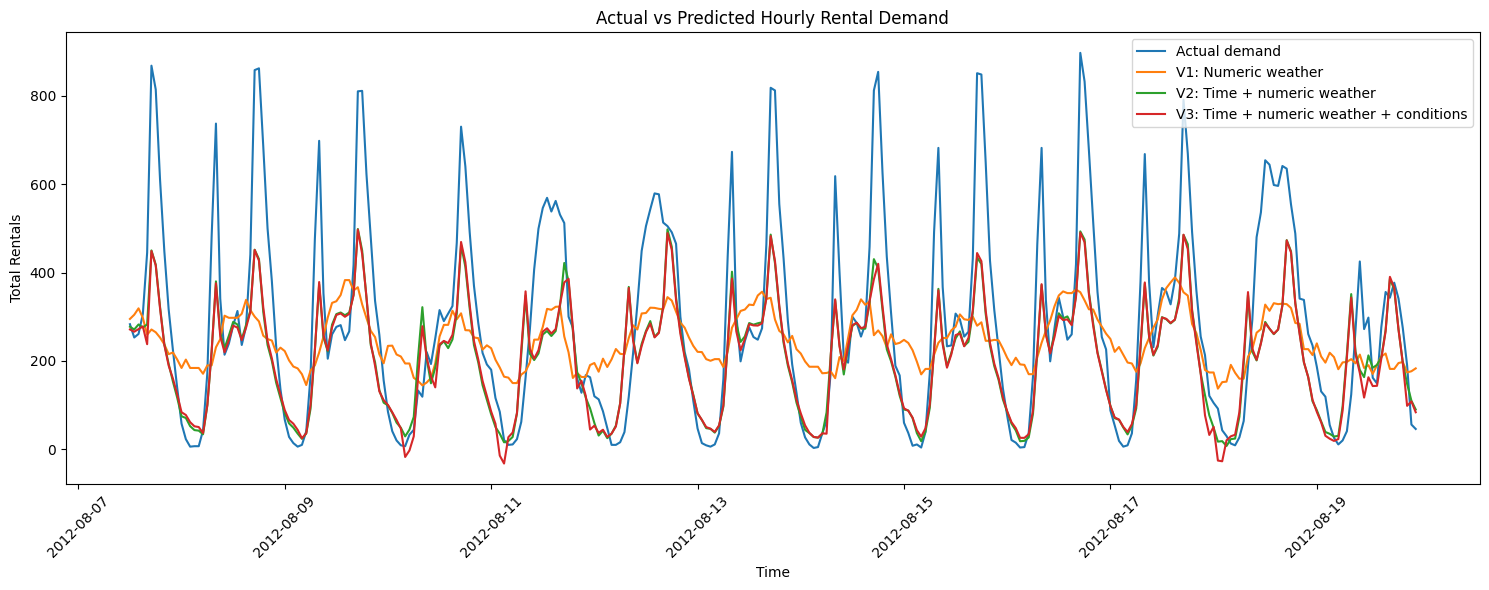

In [46]:
plot_size = min(300, len(test_data))

plt.figure(figsize=(15, 6))

plt.plot(
    test_data["hour"].iloc[:plot_size],
    y_test.iloc[:plot_size],
    label="Actual demand",
)

plt.plot(
    test_data["hour"].iloc[:plot_size],
    y_pred_V1[:plot_size],
    label="V1: Numeric weather",
)

plt.plot(
    test_data["hour"].iloc[:plot_size],
    y_pred_V2[:plot_size],
    label="V2: Time + numeric weather",
)

plt.plot(
    test_data["hour"].iloc[:plot_size],
    y_pred_V3[:plot_size],
    label="V3: Time + numeric weather + conditions",
)

plt.title("Actual vs Predicted Hourly Rental Demand")
plt.xlabel("Time")
plt.ylabel("Total Rentals")
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## 9. Conclusion

This notebook developed a series of progressively richer baseline models for predicting total hourly bike rental demand using Linear Regression and a chronological train/test split.

Linear Regression provides a transparent and interpretable baseline for this prediction task. Future modelling steps could include separately predicting `registered_count` and `direct_count`, introducing interaction features such as workday-specific peak hours, and comparing Linear Regression with models better suited to non-linear or non-negative demand prediction.
